# Lab 01 — EDA completo + Train/Test Split (Colab)
## Open-Meteo selector de ciudad + explicación de gráficos +  preguntas

**Objetivo:** flujo de EDA completo sobre datos horarios reales de clima (Open-Meteo) y un baseline con split temporal.

**Fuente:** Open-Meteo Historical Weather API (endpoint `archive-api.open-meteo.com/v1/archive`).

> Ejecuta en orden, celda por celda.


In [2]:
# === CELDA 0 — FIX pandas para Colab ===
# Qué hace:
# - Colab requiere pandas==2.2.2.
# - Si tu entorno quedó con pandas 3.x (por pip previo), esta celda fuerza 2.2.2 y reinicia.
import os, signal

TARGET = "2.2.2"
try:
    import pandas as pd
    current = pd.__version__
except Exception:
    current = None

if current != TARGET:
    print(f"[INFO] pandas actual: {current} -> reinstalando pandas=={TARGET}")
    !pip -q uninstall -y pandas
    !pip -q install "pandas==2.2.2"
    print("[INFO] Reiniciando runtime para aplicar pandas...")
    os.kill(os.getpid(), signal.SIGKILL)
else:
    print(f"[OK] pandas=={TARGET} ya está instalado.")


[OK] pandas==2.2.2 ya está instalado.


In [3]:
# === CELDA 1 — Imports + dependencias mínimas (sin romper pandas) ===
# Qué hace:
# - Importa librerías base.
# - Instala statsmodels (si falta) y scikit-learn sin estrategia agresiva.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import time
import warnings
warnings.filterwarnings("ignore")

try:
    from statsmodels.tsa.stattools import adfuller, acf, pacf
except Exception:
    !pip -q install "statsmodels==0.14.6" --upgrade-strategy only-if-needed
    from statsmodels.tsa.stattools import adfuller, acf, pacf

try:
    from sklearn.linear_model import Ridge
    from sklearn.metrics import mean_absolute_error
except Exception:
    !pip -q install "scikit-learn" --upgrade-strategy only-if-needed
    from sklearn.linear_model import Ridge
    from sklearn.metrics import mean_absolute_error

print("pandas:", pd.__version__)


pandas: 2.2.2


## 1) Selector de ciudad (Chile)

**Qué hace:** define la ubicación por lat/lon desde una lista.

- Cambia `CITY = "Santiago"` por otra opción.
- Agrega ciudades si quieres: `CITIES["MiCiudad"] = (lat, lon)`.


In [4]:
# === CELDA 2 — Selector de ciudad ===
CITIES = {
    "Santiago": (-33.45, -70.66),
    "Valparaiso": (-33.0458, -71.6197),
    "Concepcion": (-36.8270, -73.0503),
    "La Serena": (-29.9027, -71.2519),
    "Antofagasta": (-23.6500, -70.4000),
    "Iquique": (-20.2307, -70.1357),
    "Temuco": (-38.7359, -72.5904),
    "Puerto Montt": (-41.4717, -72.9369),
    "Punta Arenas": (-53.1638, -70.9171),
    "Arica": (-18.4783, -70.3126),
}

CITY = "Valparaiso"  # <-- SE PUEDE CAMBIAR AQUÍ

if CITY not in CITIES:
    raise ValueError(f"Ciudad '{CITY}' no está en CITIES. Opciones: {list(CITIES.keys())}")

LAT, LON = CITIES[CITY]
print("Ciudad:", CITY, "| LAT:", LAT, "| LON:", LON)


Ciudad: Valparaiso | LAT: -33.0458 | LON: -71.6197


## 2) Descarga Open-Meteo (reintentos + fallback de parámetros)

**Qué hace:**
- Descarga datos horarios desde Open-Meteo.
- Reintenta si hay HTTP 429/5xx.
- Prueba varias combinaciones de parámetros para evitar fallas por compatibilidad:
  - con `models=era5` / `models=era5_land` / sin `models`
  - con `cell_selection=land` / sin `cell_selection`

**Salida:** `df_raw` y `weather_hourly_raw.csv`


In [5]:
# === CELDA 3 — Descarga Open-Meteo robusta  ===
URL = "https://archive-api.open-meteo.com/v1/archive"

START_DATE = "2023-01-01" # RECOMENDACION DESCARGAR MAS DE 10 AÑOS DE DATOS
END_DATE   = "2023-03-31"
TIMEZONE   = "UTC"

HOURLY = "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation"

def request_with_retry(params, max_tries=8, base_sleep=1.0):
    # Qué hace:
    # - Reintenta ante 429/5xx con backoff exponencial (1s,2s,4s,...).
    last = None
    for i in range(max_tries):
        try:
            r = requests.get(URL, params=params, timeout=60, headers={"User-Agent":"Colab-ML-Lab01/1.0"})
            if r.status_code in (429, 500, 502, 503, 504):
                sleep = base_sleep * (2 ** i)
                print(f"[WARN] HTTP {r.status_code} -> retry en {sleep:.1f}s")
                time.sleep(sleep)
                continue
            j = r.json()
            return r.status_code, j
        except Exception as e:
            last = e
            sleep = base_sleep * (2 ** i)
            print(f"[WARN] Exception -> retry en {sleep:.1f}s | {repr(e)}")
            time.sleep(sleep)
    raise RuntimeError(f"Open-Meteo falló tras {max_tries} intentos. Último error: {repr(last)}")

def fetch_open_meteo(lat, lon, start_date, end_date, tz):
    # Qué hace:
    # - Prueba múltiples combinaciones para maximizar éxito.
    model_variants = ["era5", "era5_land", None]
    cell_variants = ["land", None]

    last_diag = None
    for cell_sel in cell_variants:
        for model in model_variants:
            params = {
                "latitude": lat,
                "longitude": lon,
                "start_date": start_date,
                "end_date": end_date,
                "hourly": HOURLY,
                "timezone": tz,
                "timeformat": "iso8601",
                "temperature_unit": "celsius",
                "wind_speed_unit": "kmh",
                "precipitation_unit": "mm",
            }
            if cell_sel is not None:
                params["cell_selection"] = cell_sel
            if model is not None:
                params["models"] = model

            status, j = request_with_retry(params)

            # manejo de error Open-Meteo tipo {"error": true, "reason": "..."}
            if isinstance(j, dict) and j.get("error", False):
                last_diag = f"model={model}, cell_selection={cell_sel}, http={status}, reason={j.get('reason')}"
                print("[WARN] Open-Meteo error:", last_diag)
                continue

            if status != 200:
                last_diag = f"model={model}, cell_selection={cell_sel}, http={status}"
                print("[WARN] HTTP no-200:", last_diag)
                continue

            hourly = j.get("hourly", {})
            if "time" not in hourly:
                last_diag = f"model={model}, cell_selection={cell_sel}, sin hourly.time"
                print("[WARN]", last_diag)
                continue

            df = pd.DataFrame({
                "timestamp": pd.to_datetime(hourly["time"]),
                "temp_C": hourly.get("temperature_2m", [np.nan]*len(hourly["time"])),
                "humidity_pct": hourly.get("relative_humidity_2m", [np.nan]*len(hourly["time"])),
                "wind_kmh": hourly.get("wind_speed_10m", [np.nan]*len(hourly["time"])),
                "rain_mm": hourly.get("precipitation", [np.nan]*len(hourly["time"])),
            })
            if len(df) == 0:
                last_diag = f"model={model}, cell_selection={cell_sel}, df vacío"
                print("[WARN]", last_diag)
                continue

            print("[OK] Descarga exitosa con:", {"model": model, "cell_selection": cell_sel})
            return df

    raise RuntimeError(f"No se pudo descargar Open-Meteo con ninguna combinación. Último diagnóstico: {last_diag}")

df_raw = fetch_open_meteo(LAT, LON, START_DATE, END_DATE, TIMEZONE)
df_raw.to_csv("dataset_lab01_valparaiso_2023Q1_hourly_dirty_seed7.csv", index=False)
print("df_raw:", df_raw.shape)
display(df_raw.head())


[OK] Descarga exitosa con: {'model': 'era5', 'cell_selection': 'land'}
df_raw: (2160, 5)


,timestamp,temp_C,humidity_pct,wind_kmh,rain_mm
0,2023-01-01 00:00:00,17.6,82,5.8,0.0
1,2023-01-01 01:00:00,17.1,85,3.3,0.0
2,2023-01-01 02:00:00,17.2,83,5.0,0.0
3,2023-01-01 03:00:00,17.1,83,4.6,0.0
4,2023-01-01 04:00:00,16.6,85,4.3,0.0


## 3) Inyectar NA/outliers controlados (practica)

**Qué hace:** crea `df_dirty` desde raw y agrega NA/outliers.

**Salida:** `df_dirty` y `weather_hourly_dirty.csv`


In [6]:
# === CELDA 4 — Inyectar NA/outliers ===
df_dirty = df_raw.copy()
np.random.seed(7)
n = len(df_dirty)

for col in ["temp_C","humidity_pct","wind_kmh","rain_mm"]:
    idx = np.random.choice(n, size=max(1, int(n*0.05)), replace=False)
    df_dirty.loc[idx, col] = np.nan

block_start = int(n*0.20)
df_dirty.loc[block_start:block_start+10, ["temp_C","humidity_pct"]] = np.nan

df_dirty.loc[np.random.choice(n, 5, replace=False), "temp_C"] += 15
df_dirty.loc[np.random.choice(n, 5, replace=False), "wind_kmh"] += 25

df_dirty.to_csv("dataset_lab01_valparaiso_2023Q1_hourly_dirty_seed7.csv", index=False)
print("NA por columna:\n", df_dirty.isna().sum())


NA por columna:
 timestamp         0
temp_C          119
humidity_pct    117
wind_kmh        108
rain_mm         108
dtype: int64


## 4) Auditoría rápida (sin gráficos)

**Qué hace:** ordena por tiempo, elimina duplicados, revisa gaps > 1h.


In [7]:
# === CELDA 5 — Auditoría rápida ===
df = pd.read_csv("dataset_lab01_valparaiso_2023Q1_hourly_dirty_seed7.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").drop_duplicates()
df_ts = df.set_index("timestamp").sort_index()

delta = df["timestamp"].diff().value_counts().head(10)
print("Frecuencias (diff) más comunes:")
display(delta)

gaps = df[df["timestamp"].diff() > pd.Timedelta("1h")][["timestamp"]]
print("Gaps > 1h (primeros 5):")
display(gaps.head())


Frecuencias (diff) más comunes:


timestamp
0 days 01:00:00    2159
Name: count, dtype: int64

Gaps > 1h (primeros 5):


,timestamp


# Gráficos y significado

Cada sección incluye un gráfico y su interpretación.


## Gráfico 1 — % NA por día  
**Muestra:** porcentaje diario de NA por variable.  
**Significa:** picos altos = NA por bloques (cortes).  
**Sugiere:** imputación temporal (interp/ffill/bfill/by-hour).


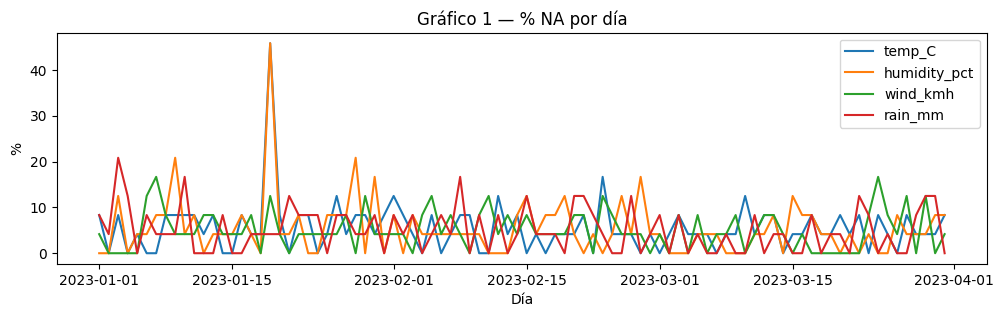

In [8]:
na_day = df_ts.isna().resample("D").mean()*100
plt.figure(figsize=(12,3))
for col in ["temp_C","humidity_pct","wind_kmh","rain_mm"]:
    plt.plot(na_day.index, na_day[col], label=col)
plt.title("Gráfico 1 — % NA por día")
plt.xlabel("Día"); plt.ylabel("%")
plt.legend(); plt.show()


## Gráfico 2 — Mapa de NA (1=NA)  
**Muestra:** localización temporal de NA por variable.  
**Significa:** bandas = bloque NA; puntos = NA disperso.  
**Sugiere:** decide estrategia por tipo de NA.


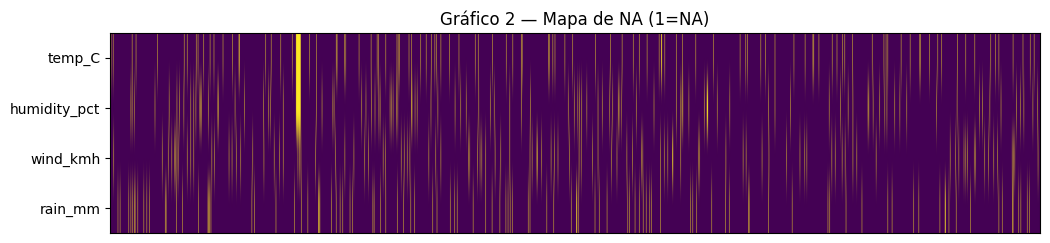

In [9]:
miss = df_ts[["temp_C","humidity_pct","wind_kmh","rain_mm"]].isna().astype(int)
plt.figure(figsize=(12,2.6))
plt.imshow(miss.T, aspect="auto")
plt.yticks(range(miss.shape[1]), miss.columns)
plt.xticks([])
plt.title("Gráfico 2 — Mapa de NA (1=NA)")
plt.show()


## Gráfico 3 — Comparación de imputación (Temp)  
**Muestra:** cómo cada método rellena un bloque NA.  
**Significa:** mean aplana; ffill/bfill sostienen; interp suaviza; by-hour respeta ciclo diurno.  
**Sugiere:** seleccionar método final por variable con evidencia.


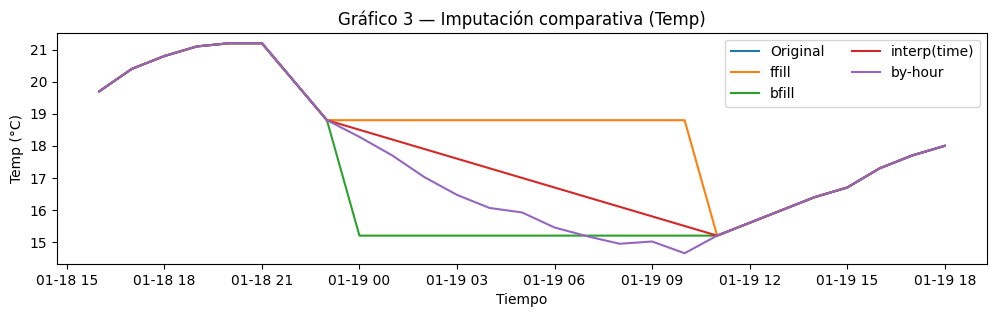

In [10]:
df_mean  = df_ts.fillna(df_ts.mean(numeric_only=True))
df_ffill = df_ts.ffill()
df_bfill = df_ts.bfill()
df_interp = df_ts.interpolate(method="time", limit_direction="both")

hour_means = df_ts.groupby(df_ts.index.hour).mean(numeric_only=True)
df_byhour = df_ts.copy()
for col in ["temp_C","humidity_pct","wind_kmh"]:
    m = df_byhour[col].isna()
    df_byhour.loc[m, col] = [hour_means.loc[h, col] for h in df_byhour.index[m].hour]
df_byhour["rain_mm"] = df_byhour["rain_mm"].fillna(0.0)

w0 = df_ts.index[max(0, block_start-8)]
w1 = df_ts.index[min(len(df_ts)-1, block_start+18)]

plt.figure(figsize=(12,3))
plt.plot(df_ts.loc[w0:w1].index, df_ts.loc[w0:w1,"temp_C"], label="Original")
plt.plot(df_ffill.loc[w0:w1].index, df_ffill.loc[w0:w1,"temp_C"], label="ffill")
plt.plot(df_bfill.loc[w0:w1].index, df_bfill.loc[w0:w1,"temp_C"], label="bfill")
plt.plot(df_interp.loc[w0:w1].index, df_interp.loc[w0:w1,"temp_C"], label="interp(time)")
plt.plot(df_byhour.loc[w0:w1].index, df_byhour.loc[w0:w1,"temp_C"], label="by-hour")
plt.title("Gráfico 3 — Imputación comparativa (Temp)")
plt.xlabel("Tiempo"); plt.ylabel("Temp (°C)")
plt.legend(ncol=2); plt.show()

# Selección final base
df_clean = df_interp.copy()


## Gráfico 4 — Temp diaria (mean)  
**Muestra:** tendencia/estacionalidad en escala diaria.  
**Significa:** reduce ruido horario.  
**Sugiere:** útil para ADF/ACF/PACF.


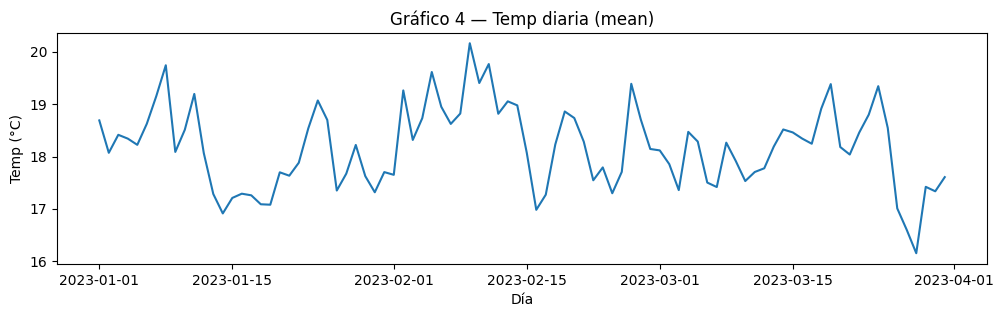

In [11]:
daily = df_clean.resample("D").agg({
    "temp_C":"mean",
    "humidity_pct":"mean",
    "wind_kmh":"mean",
    "rain_mm":"sum"
})
plt.figure(figsize=(12,3))
plt.plot(daily.index, daily["temp_C"])
plt.title("Gráfico 4 — Temp diaria (mean)")
plt.xlabel("Día"); plt.ylabel("Temp (°C)")
plt.show()


## Gráfico 5 — Perfil promedio por hora  
**Muestra:** ciclo diurno típico (0..23).  
**Significa:** hora de máximo/mínimo promedio.  
**Sugiere:** features estacionales y/o imputación by-hour.


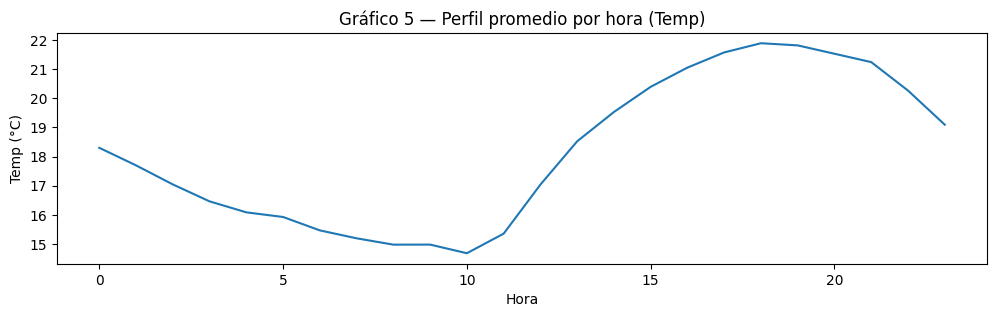

In [12]:
hour_profile = df_clean.groupby(df_clean.index.hour).mean(numeric_only=True)
plt.figure(figsize=(12,3))
plt.plot(hour_profile.index, hour_profile["temp_C"])
plt.title("Gráfico 5 — Perfil promedio por hora (Temp)")
plt.xlabel("Hora"); plt.ylabel("Temp (°C)")
plt.show()


## Gráfico 6 — Histograma Temp  
**Muestra:** distribución de temperatura.  
**Significa:** sesgo/colas/multimodalidad.  
**Sugiere:** detectar extremos o mezclas de regímenes.


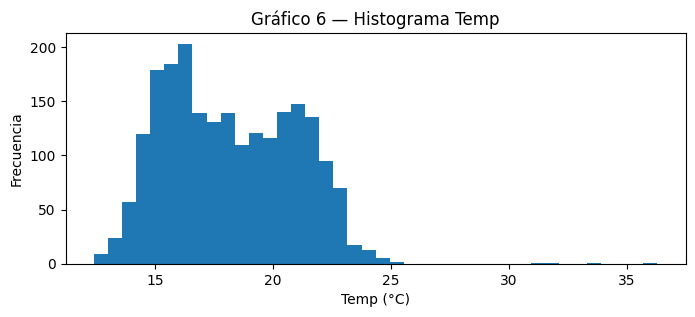

In [13]:
plt.figure(figsize=(8,3))
plt.hist(df_clean["temp_C"].dropna(), bins=40)
plt.title("Gráfico 6 — Histograma Temp")
plt.xlabel("Temp (°C)"); plt.ylabel("Frecuencia")
plt.show()


## Gráfico 7 — Boxplot (Temp/Hum/Wind)  
**Muestra:** mediana, IQR, outliers.  
**Significa:** puntos fuera = potenciales outliers.  
**Sugiere:** decidir clipping/robustez vs mantener eventos reales.


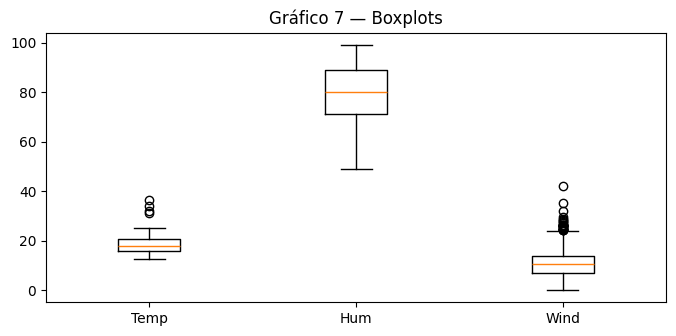

In [14]:
plt.figure(figsize=(8,3.5))
plt.boxplot([
    df_clean["temp_C"].dropna(),
    df_clean["humidity_pct"].dropna(),
    df_clean["wind_kmh"].dropna()
], tick_labels=["Temp","Hum","Wind"])
plt.title("Gráfico 7 — Boxplots")
plt.show()


## Gráfico 8–9 — Pearson vs Spearman  
**Muestra:** matrices de correlación.  
**Significa:** Spearman robusto a outliers/no-linealidad; Pearson lineal.  
**Sugiere:** si difieren mucho, revisar outliers o forma de relación.


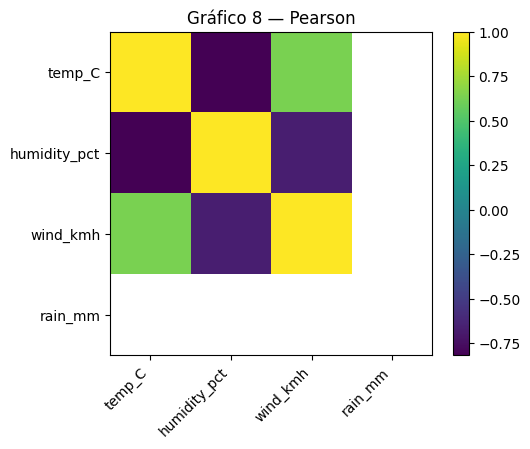

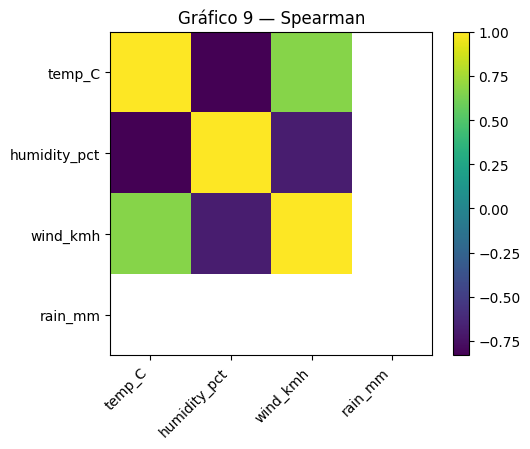

In [15]:
num = df_clean[["temp_C","humidity_pct","wind_kmh","rain_mm"]]
corr_p = num.corr(method="pearson")
corr_s = num.corr(method="spearman")

plt.figure(figsize=(5.2,4.2))
plt.imshow(corr_p.values, aspect="auto")
plt.xticks(range(len(corr_p.columns)), corr_p.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_p.index)), corr_p.index)
plt.colorbar(); plt.title("Gráfico 8 — Pearson")
plt.show()

plt.figure(figsize=(5.2,4.2))
plt.imshow(corr_s.values, aspect="auto")
plt.xticks(range(len(corr_s.columns)), corr_s.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_s.index)), corr_s.index)
plt.colorbar(); plt.title("Gráfico 9 — Spearman")
plt.show()


## Gráfico 10 — Scatter Temp vs Humedad  
**Muestra:** relación real (no solo coeficiente).  
**Significa:** linealidad/no-linealidad/heterocedasticidad.  
**Sugiere:** si no es lineal, modelos lineales pueden ser limitados.


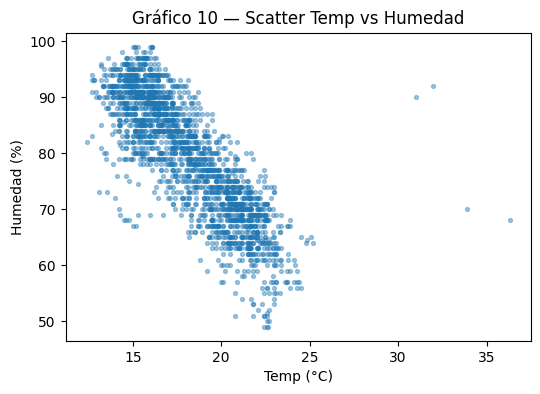

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean["temp_C"], df_clean["humidity_pct"], s=8, alpha=0.4)
plt.title("Gráfico 10 — Scatter Temp vs Humedad")
plt.xlabel("Temp (°C)"); plt.ylabel("Humedad (%)")
plt.show()


## Gráfico 11–13 — Rolling / ADF / ACF / PACF  
**Muestra:** estructura temporal y estacionariedad.  
**Significa:** ADF p alto = no estacionaria (común). ACF/PACF sugieren lags/estacionalidad.  
**Sugiere:** usar lags/rolling y split temporal.


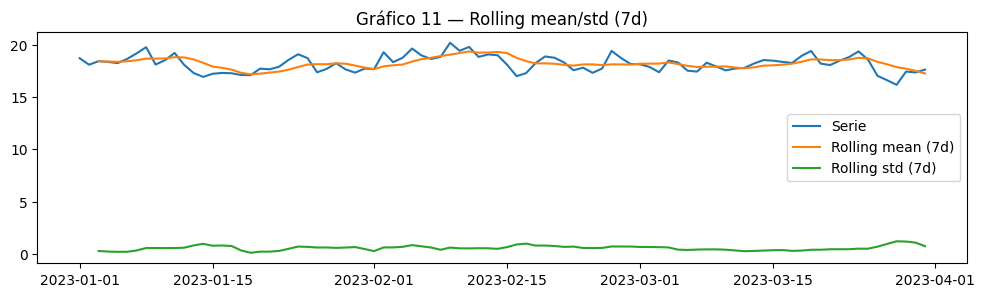

ADF: -4.376128959046697 | p-value: 0.00032707691940807337


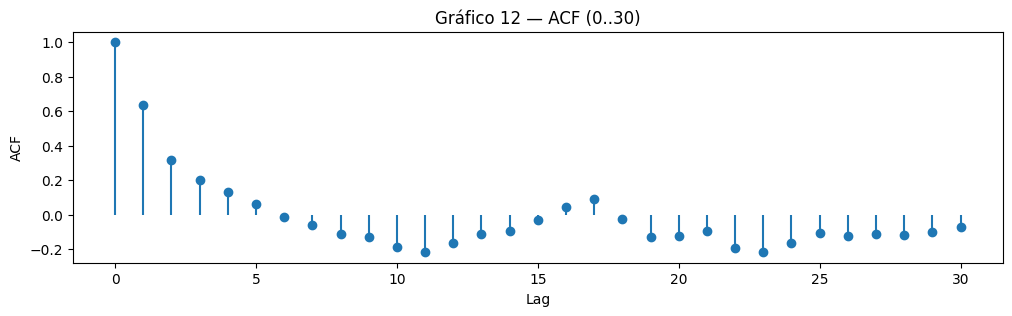

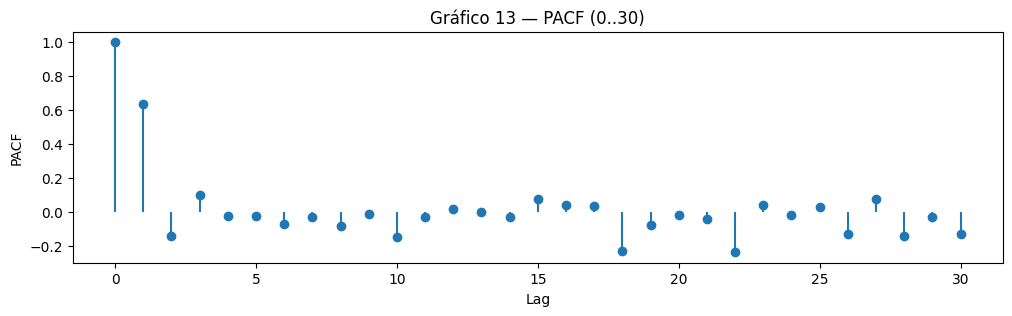

In [17]:
y = daily["temp_C"].dropna()

roll_mean = y.rolling(7, min_periods=3).mean()
roll_std  = y.rolling(7, min_periods=3).std()

plt.figure(figsize=(12,3))
plt.plot(y.index, y.values, label="Serie")
plt.plot(roll_mean.index, roll_mean.values, label="Rolling mean (7d)")
plt.plot(roll_std.index, roll_std.values, label="Rolling std (7d)")
plt.title("Gráfico 11 — Rolling mean/std (7d)")
plt.legend(); plt.show()

adf_stat, p_value, *_ = adfuller(y, autolag="AIC")
print("ADF:", adf_stat, "| p-value:", p_value)

max_allowed = (len(y)//2) - 1
nlags = max(1, min(30, max_allowed))

acf_vals = acf(y, nlags=nlags, fft=True)
pacf_vals = pacf(y, nlags=nlags, method="ywm")

plt.figure(figsize=(12,3))
plt.stem(range(len(acf_vals)), acf_vals, basefmt=" ")
plt.title(f"Gráfico 12 — ACF (0..{nlags})")
plt.xlabel("Lag"); plt.ylabel("ACF"); plt.show()

plt.figure(figsize=(12,3))
plt.stem(range(len(pacf_vals)), pacf_vals, basefmt=" ")
plt.title(f"Gráfico 13 — PACF (0..{nlags})")
plt.xlabel("Lag"); plt.ylabel("PACF"); plt.show()


## Gráfico 14 — Baseline Ridge (split temporal)  
**Muestra:** predicción vs real en test futuro + MAE.  
**Significa:** desempeño mínimo viable sin leakage.  
**Sugiere:** mejorar features (lags/rolling) o cambiar modelo.


MAE: 0.6032449297240827


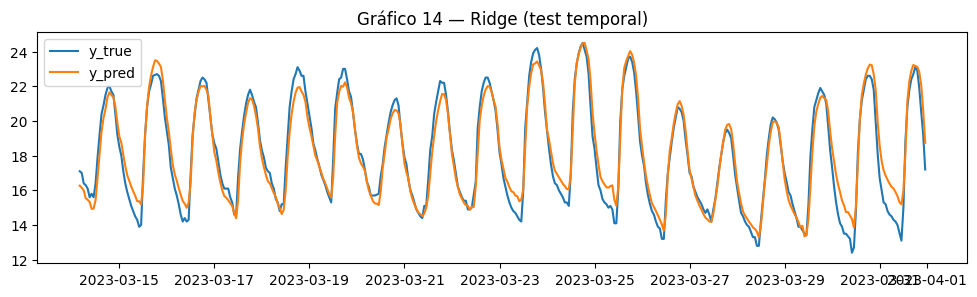

In [18]:
df_feat = df_clean.copy()
df_feat["temp_lag1h"]  = df_feat["temp_C"].shift(1)
df_feat["temp_lag24h"] = df_feat["temp_C"].shift(24)
df_feat["temp_rm24h"]  = df_feat["temp_C"].rolling(24, min_periods=12).mean()
df_feat["rain_sum24h"] = df_feat["rain_mm"].rolling(24, min_periods=12).sum()
df_feat = df_feat.dropna()

features = ["humidity_pct","wind_kmh","rain_mm","temp_lag1h","temp_lag24h","temp_rm24h","rain_sum24h"]

cut = int(len(df_feat)*0.8)
train = df_feat.iloc[:cut]
test  = df_feat.iloc[cut:]

X_train, y_train = train[features], train["temp_C"]
X_test,  y_test  = test[features],  test["temp_C"]

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

plt.figure(figsize=(12,3))
plt.plot(y_test.index, y_test.values, label="y_true")
plt.plot(y_test.index, pred, label="y_pred")
plt.title("Gráfico 14 — Ridge (test temporal)")
plt.legend(); plt.show()


In [19]:
# === Guardar y descargar predicciones (CSV) ===
import pandas as pd

# 1) Construir DataFrame con timestamp + real + predicho
df_pred = pd.DataFrame({
    "timestamp": pd.to_datetime(y_test.index),   # si tu índice ya es datetime
    "y_true_temp_C": y_test.values,
    "y_pred_temp_C": pred
})

# (Opcional) agrega error absoluto
df_pred["abs_error"] = (df_pred["y_true_temp_C"] - df_pred["y_pred_temp_C"]).abs()

# 2) Guardar CSV
pred_csv = "predicciones_ridge_test.csv"
df_pred.to_csv(pred_csv, index=False)
print("OK -> guardado:", pred_csv)
display(df_pred.head())

# 3) Descargar en Colab (dispara la descarga en el navegador)
from google.colab import files
files.download(pred_csv)

OK -> guardado: predicciones_ridge_test.csv


,timestamp,y_true_temp_C,y_pred_temp_C,abs_error
0,2023-03-14 04:00:00,17.1,16.270300,0.829700
1,2023-03-14 05:00:00,17.0,16.146715,0.853285
2,2023-03-14 06:00:00,16.4,15.995774,0.404226
3,2023-03-14 07:00:00,16.3,15.546597,0.753403
4,2023-03-14 08:00:00,16.1,15.460975,0.639025


ModuleNotFoundError: No module named 'google.colab'

# 6 preguntas (entrega del laboratorio — interpretación)

1) **Valores faltantes (Gráfico 1 y/o 2):**  
   ¿En qué variable ves más NA? ¿Los NA aparecen en bloques o dispersos? (2–3 líneas).

   \
   La variable con más NA porcentualmente en ciertos días en rain_mm (con un maximo del 20.83% el 3 de enero), los NA aparecen tanto dispersos (puntos en el gráfico 2) como en bloques (bandas horizontales en el gráfico 2 para temp_c y humidity_pct).

2) **Imputación (Gráfico 3):**  
   ¿Qué método se ve más razonable para rellenar la temperatura: ffill, bfill, interpolación, by-hour o media? ¿Por qué? (1–2 frases).

   \
   Para rellenar la temperatura, el método de interpolación (interp(time)) se ve con mucho mas sentido. Esto se debe a que genera una curva suave que sigue la tendencia de los datos, evitando los cambios bruscos o las mesetas que se observan con ffill, bfill o la media.

3) **Ciclo diario (Gráfico 5):**  
   ¿A qué hora está el máximo de temperatura promedio? ¿A qué hora está el mínimo?

   \
   El máximo de temperatura promedio se encuentra alrededor de las 19:00 (7 PM), mientras que el mínimo de temperatura promedio se encuentra alrededor de las 10:00 (10 AM).

4) **Distribución y outliers (Gráfico 6 y 7):**  
   ¿Ves valores extremos? ¿En cuál variable se notan más (Temp/Hum/Wind)? (2–3 líneas).

   \
   Sí, se ven valores extremos, especialmente en las variables temp_C y wind_kmh, se observan puntos individuales por encima y por debajo de los 'bigotes' para estas dos variables, lo que indica la presencia de outliers.

5) **Relación entre variables (Gráfico 10):**  
   ¿Temp vs Humedad va hacia abajo, hacia arriba, o sin patrón claro? Explica en palabras simples (2–3 líneas).

   \
   La relación entre la Temperatura y la Humedad va hacia abajo; es decir, a medida que la temperatura aumenta, la humedad tiende a disminuir. Esto indica una correlación negativa fuerte (alrededor de -0.83, según las correlaciones de Pearson y Spearman).

6) **Baseline (Gráfico 14):**  
   ¿La predicción sigue bien a la real o se desfasa? Menciona una zona del gráfico donde se note.
   
   \
   La predicción del modelo baseline con Ridge generalmente sigue la tendencia de la serie real de temperatura. Sin embargo, se observa que se desfasa un poco en algunos puntos. Por ejemplo, en la primera parte del test, la predicción (y_pred) está consistentemente por debajo de la temperatura real (y_true), mostrando una subestimación.

## Export para entrega

Genera:
- `weather_hourly_raw.csv`
- `weather_hourly_dirty.csv`
- `weather_features_final.csv`
- `lab01_entrega.zip`


In [20]:
df_raw.to_csv("weather_hourly_raw.csv", index=False)
df.reset_index(drop=True).to_csv("weather_hourly_dirty.csv", index=False)
df_feat.reset_index().rename(columns={"index":"timestamp"}).to_csv("weather_features_final.csv", index=False)

!zip -q lab01_entrega.zip weather_hourly_raw.csv weather_hourly_dirty.csv weather_features_final.csv
print("[OK] lab01_entrega.zip creado.")


[OK] lab01_entrega.zip creado.


"zip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
